# 🔬 Lab 11: Dimensionality Reduction
**BINF 4002 – Machine Learning for Health**

The Wisconsin Breast Cancer dataset has 30 features. A single-cell RNA-seq experiment
can produce 20,000. An EHR dataset might have thousands of diagnosis codes, lab values,
and medications. High-dimensional data is the norm in biomedical ML — and it causes
real problems.

**Dimensionality reduction (DR)** addresses this by mapping high-dimensional data into
a lower-dimensional space while preserving the information that matters. DR serves
three distinct purposes:
1. **Visualization**: project data to 2D/3D for human inspection
2. **Preprocessing**: reduce features before feeding into a downstream model
3. **Interpretation**: discover which features (or combinations) capture the most variation

Different methods optimize different objectives — PCA minimizes *reconstruction error*,
t-SNE preserves *local neighborhoods*, UMAP balances *local and global structure*.
Understanding what each method preserves (and discards) is critical to avoiding
misinterpretation.

### Learning Objectives
1. Understand the distinction between feature selection and feature extraction
2. Implement PCA from eigendecomposition; interpret explained variance
3. Compare linear (PCA) and nonlinear (t-SNE, UMAP) methods
4. Understand the reconstruction loss (PCA) vs. neighborhood-preservation objective (t-SNE/UMAP)
5. Recognize common pitfalls and misinterpretations of DR visualizations

## Set-up
### Upload data
⚠️ First, you need to upload the pre-processed data from `lab0`. If you have issues with running the first lab, you can also download the data [here](https://drive.google.com/file/d/1mCz8VqpX0F5DzOTnfb5NzpxNAMBrzD-_/view?usp=drive_link).

In [1]:
import os

pkl_path = 'processed_data.pkl'
if os.path.exists(pkl_path):
    print("✅ Data File Found!")
else:
    raise FileNotFoundError(
        "processed_data.pkl not found! "
        "Make sure you have run Lab 0 (lab0_preprocessing.ipynb) in full and "
        "downloaded the output (or used the link above), and uploaded it here."
    )

✅ Data File Found!


In [2]:
# Install UMAP (may take a minute)
# (pip install handled by the book's isolated env)

### Imports and Data Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

# ── Load the full 30-feature standardized dataset ─────────────────────────────
with open('processed_data.pkl', 'rb') as f:
    d = pickle.load(f)

# Combine all splits — DR is typically applied to the full dataset
X = np.vstack([d['X_train'], d['X_val'], d['X_test']])
y = np.concatenate([d['y_train'], d['y_val'], d['y_test']])
feature_names = d['feature_names']
class_names = d['class_names']  # ['malignant', 'benign']

# We also keep the original train/val/test splits for Part 6
X_train, y_train = d['X_train'], d['y_train']
X_val, y_val = d['X_val'], d['y_val']
X_test, y_test = d['X_test'], d['y_test']

n_samples, n_features = X.shape
print(f"Dataset: {n_samples} patients, {n_features} features")
print(f"Labels (for color-coding only): {dict(zip(class_names, np.bincount(y)))}")

Dataset: 569 patients, 30 features
Labels (for color-coding only): {'malignant': np.int64(212), 'benign': np.int64(357)}


---
## Part 1 — Motivation: The Curse of Dimensionality

In high-dimensional spaces, distances between points become increasingly similar.
This is the **curse of dimensionality** — and it directly harms algorithms that
depend on distance (K-NN, K-Means, kernel methods).

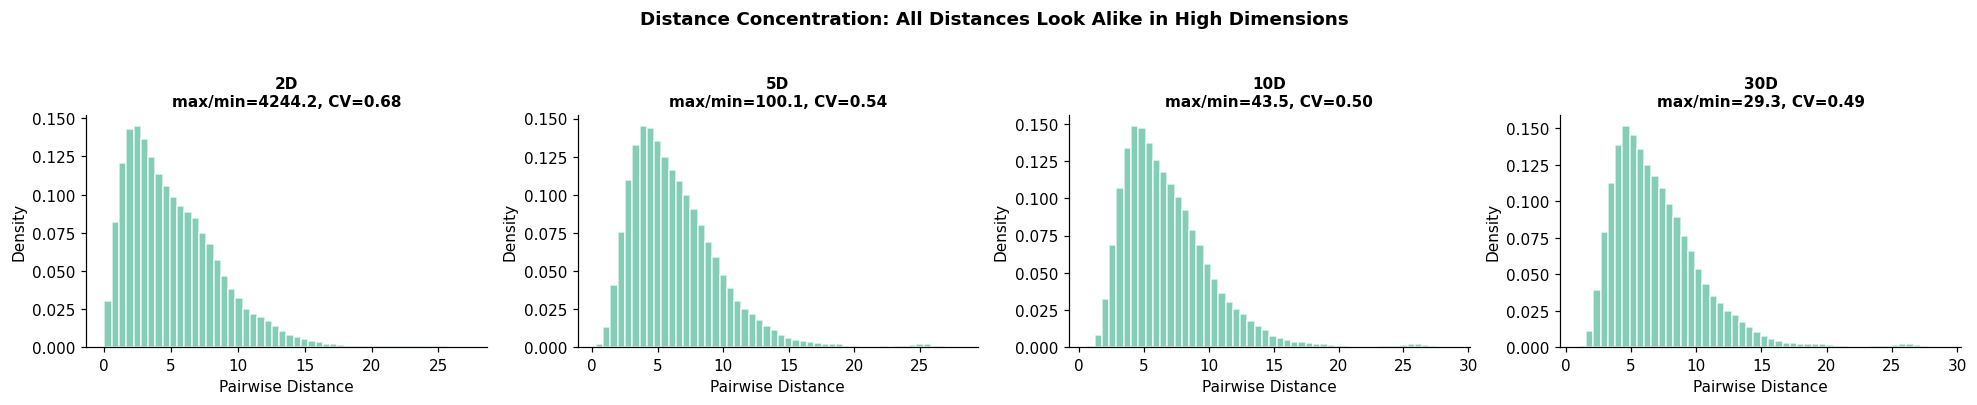

As dimensionality increases:
  • The max/min distance ratio decreases → all distances become similar
  • The coefficient of variation (CV) decreases → distribution concentrates
  • K-NN can't distinguish near from far neighbors → performance degrades


In [4]:
# ── Distance concentration in high dimensions ────────────────────────────────
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

# Compare distance distributions in different dimensionalities
dims_to_test = [2, 5, 10, 30]

fig, axes = plt.subplots(1, len(dims_to_test), figsize=(18, 3.5))

for ax, dim in zip(axes, dims_to_test):
    if dim == 30:
        X_proj = X  # full space
    else:
        pca_proj = PCA(n_components=dim, random_state=42)
        X_proj = pca_proj.fit_transform(X)

    dists = pairwise_distances(X_proj).ravel()
    dists = dists[dists > 0]  # remove self-distances

    ratio = dists.max() / dists.min()
    cv = dists.std() / dists.mean()  # coefficient of variation

    ax.hist(dists, bins=50, color=sns.color_palette('Set2')[0], edgecolor='white',
            alpha=0.8, density=True)
    ax.set_xlabel('Pairwise Distance')
    ax.set_ylabel('Density')
    ax.set_title(f'{dim}D\nmax/min={ratio:.1f}, CV={cv:.2f}',
                 fontweight='bold', fontsize=10)

plt.suptitle('Distance Concentration: All Distances Look Alike in High Dimensions',
             fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print("As dimensionality increases:")
print("  • The max/min distance ratio decreases → all distances become similar")
print("  • The coefficient of variation (CV) decreases → distribution concentrates")
print("  • K-NN can't distinguish near from far neighbors → performance degrades")

### 🤔 Reflection 1.1 — Why Reduce Dimensions?

1. If all pairwise distances become similar in high dimensions, what happens to K-NN?
   To K-Means (which uses distances to assign clusters)? Why does this motivate
   dimensionality reduction as a *preprocessing* step, not just a visualization tool?

2. Dimensionality reduction can be done by **feature selection** (pick a subset of
   original features) or **feature extraction** (create new features that are
   combinations of originals). When would you prefer each? (Hint: feature selection
   preserves interpretability; feature extraction can capture more information.)

3. Our dataset has 30 features and 569 samples. The "rule of thumb" is that you need
   at least 5–10 samples per feature for reliable learning. Are we in danger here?
   What about a genomics dataset with 20,000 genes and 200 patients?

---
## Part 2 — PCA: The Reconstruction Loss

**Principal Component Analysis (PCA)** finds the directions of maximum variance in
the data. Equivalently, it minimizes the **reconstruction error** when projecting
data onto a lower-dimensional subspace.

The algorithm:
1. Center the data: $\tilde{X} = X - \bar{X}$
2. Compute the covariance matrix: $C = \frac{1}{n-1} \tilde{X}^T \tilde{X}$
3. Eigendecompose: $C = V \Lambda V^T$ (eigenvectors = principal directions, eigenvalues = variance along each)
4. Project onto top $k$ eigenvectors: $Z = \tilde{X} V_k$

In [5]:
def pca_from_scratch_solution(X, n_components):
    """
    PCA via eigendecomposition.
    """
    n, d = X.shape

    # Step 1: Center the data
    mean = X.mean(axis=0)
    X_centered = X - mean

    # Step 2: Covariance matrix
    C = (1 / (n - 1)) * X_centered.T @ X_centered

    # Step 3: Eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(C)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Step 4: Project onto top-k eigenvectors
    eigvecs_k = eigvecs[:, :n_components]
    Z = X_centered @ eigvecs_k

    return Z, eigvecs_k, eigvals, mean


# Verify against sklearn
from sklearn.decomposition import PCA

Z_sol, V_k_sol, eigvals_sol, mean_sol = pca_from_scratch_solution(X, n_components=2)
pca_sk = PCA(n_components=2, random_state=42)
Z_sk = pca_sk.fit_transform(X)

for i in range(2):
    corr = np.abs(np.corrcoef(Z_sol[:, i], Z_sk[:, i])[0, 1])
    print(f"PC{i+1} correlation: {corr:.6f}  {'✅' if corr > 0.999 else '⚠️'}")


PC1 correlation: 1.000000  ✅
PC2 correlation: 1.000000  ✅


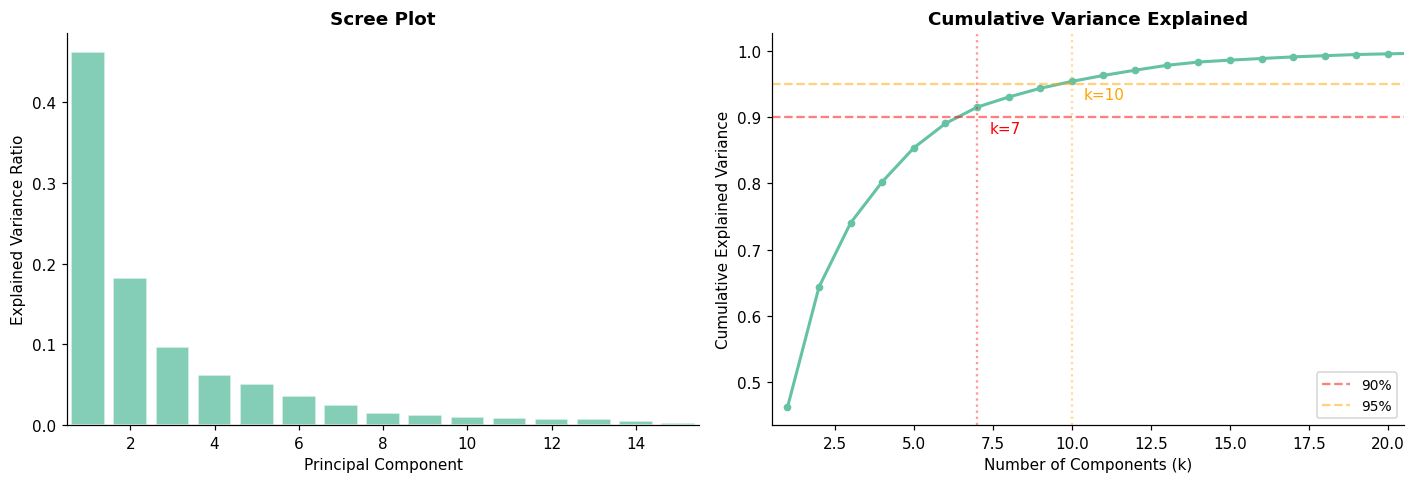

Components for 90% variance: 7 (out of 30)
Components for 95% variance: 10 (out of 30)
PC1 alone captures 46.2% of total variance.


In [6]:
# ── Scree plot: explained variance ───────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X)
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Individual explained variance
ax = axes[0]
ax.bar(range(1, n_features + 1), evr, color=sns.color_palette('Set2')[0],
       edgecolor='white', alpha=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot', fontweight='bold')
ax.set_xlim(0.5, 15.5)

# Cumulative explained variance
ax = axes[1]
ax.plot(range(1, n_features + 1), cum_evr, 'o-', markersize=4, linewidth=2)
ax.axhline(0.90, color='red', linestyle='--', alpha=0.5, label='90%')
ax.axhline(0.95, color='orange', linestyle='--', alpha=0.5, label='95%')

n_90 = np.searchsorted(cum_evr, 0.90) + 1
n_95 = np.searchsorted(cum_evr, 0.95) + 1
ax.axvline(n_90, color='red', linestyle=':', alpha=0.4)
ax.axvline(n_95, color='orange', linestyle=':', alpha=0.4)
ax.annotate(f'k={n_90}', (n_90, 0.90), fontsize=10, color='red',
            textcoords='offset points', xytext=(8, -10))
ax.annotate(f'k={n_95}', (n_95, 0.95), fontsize=10, color='orange',
            textcoords='offset points', xytext=(8, -10))

ax.set_xlabel('Number of Components (k)')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Variance Explained', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0.5, 20.5)

plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {n_90} (out of {n_features})")
print(f"Components for 95% variance: {n_95} (out of {n_features})")
print(f"PC1 alone captures {evr[0]:.1%} of total variance.")

In [7]:
def pca_reconstruction_error_solution(X, n_components):
    """
    Compute PCA reconstruction error for a given number of components.
    """
    Z, V_k, _, mean = pca_from_scratch_solution(X, n_components)

    # Reconstruct
    X_reconstructed = Z @ V_k.T + mean

    # Reconstruction error: mean of per-sample squared errors
    error = np.mean(np.sum((X - X_reconstructed) ** 2, axis=1))
    return error


# Verify
for k in [1, 2, 5, 10, 30]:
    err = pca_reconstruction_error_solution(X, k)
    print(f"k={k:2d}: reconstruction error = {err:.4f}")
print(f"k=30 should be ≈0 (full reconstruction)")


k= 1: reconstruction error = 16.4924
k= 2: reconstruction error = 10.9131
k= 5: reconstruction error = 4.4790
k=10: reconstruction error = 1.4069
k=30: reconstruction error = 0.0000
k=30 should be ≈0 (full reconstruction)


### 🤔 Reflection 2.1 — PCA and Variance

1. PCA finds directions of **maximum variance**. But maximum variance $\neq$ maximum
   class separation. Imagine two overlapping Gaussian blobs that differ along a
   direction with small variance but are spread widely along an orthogonal direction.
   PC1 would capture the spread (useless for classification) and miss the separation.
   Can you think of a clinical example where the main source of variation in the data
   is *not* the clinically important one?

2. With only a handful of components, we capture 90% of the variance in 30 features.
   What does this tell you about the **intrinsic dimensionality** of this dataset?
   Are the 30 features truly independent, or are many of them redundant?

3. Reconstruction error is already fairly low with just 2 components.
   Does low reconstruction error imply good downstream classification? Why or why not?

---
## Part 3 — PCA Loadings and Interpretability

Unlike t-SNE or UMAP, PCA is **interpretable**: each principal component is a linear
combination of the original features. The **loadings** (weights in that combination)
tell us which features contribute most to each component.

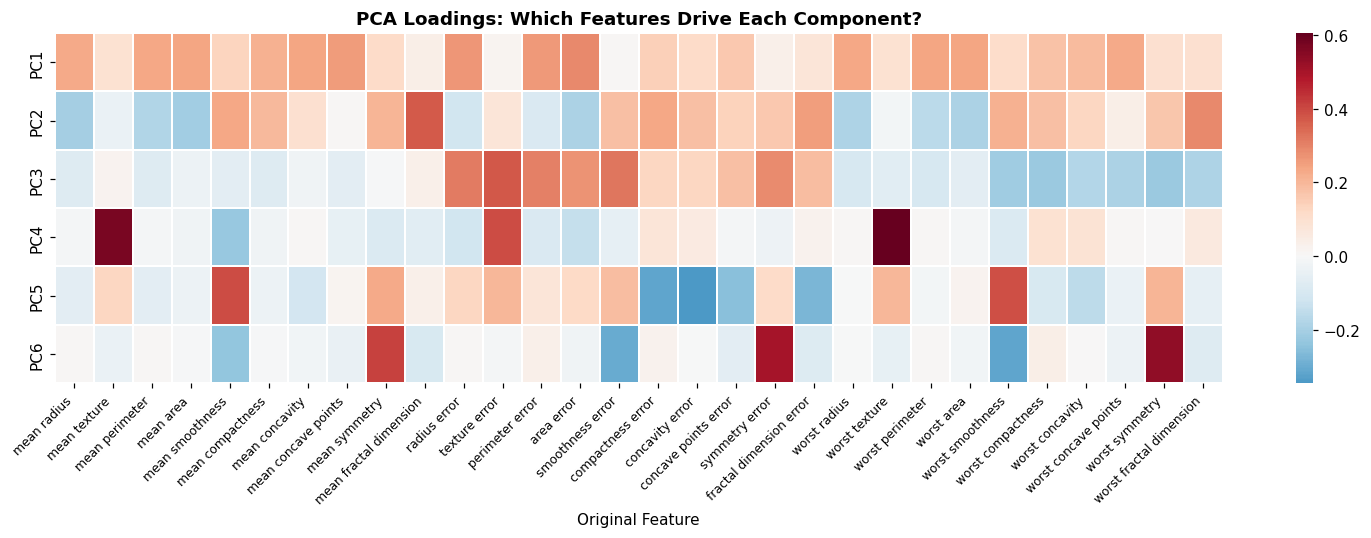


PC1 top features:
  area error                 loading = +0.293
  radius error               loading = +0.265
  perimeter error            loading = +0.262
  mean concave points        loading = +0.258
  worst perimeter            loading = +0.240

PC2 top features:
  mean fractal dimension     loading = +0.367
  worst fractal dimension    loading = +0.291
  fractal dimension error    loading = +0.250
  compactness error          loading = +0.235
  mean smoothness            loading = +0.235


In [8]:
# ── Loadings heatmap ─────────────────────────────────────────────────────────
n_pcs_show = 6
loadings = pca_full.components_[:n_pcs_show]  # shape (n_pcs, n_features)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(loadings, xticklabels=feature_names, yticklabels=[f'PC{i+1}' for i in range(n_pcs_show)],
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.3)
ax.set_title('PCA Loadings: Which Features Drive Each Component?', fontweight='bold')
ax.set_xlabel('Original Feature')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Top features for PC1 and PC2
for pc_idx, pc_name in enumerate(['PC1', 'PC2']):
    abs_loadings = np.abs(loadings[pc_idx])
    top5_idx = np.argsort(abs_loadings)[-5:][::-1]
    print(f"\n{pc_name} top features:")
    for idx in top5_idx:
        print(f"  {feature_names[idx]:25s}  loading = {loadings[pc_idx, idx]:+.3f}")

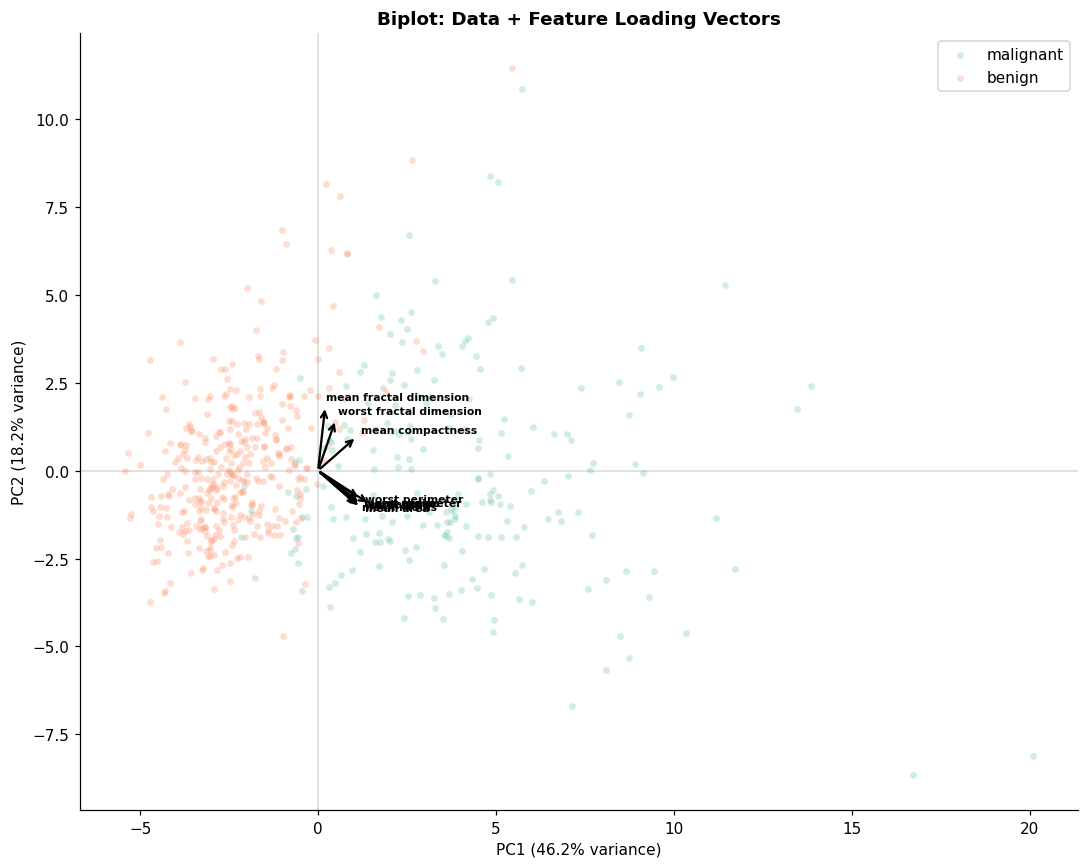

Arrows point in the direction each feature increases most.
Features pointing in similar directions are correlated.
Features pointing toward the malignant cluster are associated with malignancy.


In [9]:
# ── Biplot: data + loading vectors ───────────────────────────────────────────
Z_2d = pca_full.transform(X)[:, :2]
loadings_2d = pca_full.components_[:2]  # (2, 30)

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter data colored by label
colors = sns.color_palette('Set2', 2)
for k, name in enumerate(class_names):
    mask = y == k
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], alpha=0.3, s=20, color=colors[k],
               edgecolors='white', linewidth=0.2, label=name)

# Overlay loading vectors (scaled for visibility)
scale = 5  # scale factor for arrows
# Only plot the top-10 most important features (by total loading magnitude)
total_loading = np.sqrt(loadings_2d[0]**2 + loadings_2d[1]**2)
top10_idx = np.argsort(total_loading)[-10:]

for idx in top10_idx:
    ax.annotate('', xy=(loadings_2d[0, idx] * scale, loadings_2d[1, idx] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings_2d[0, idx] * scale * 1.1, loadings_2d[1, idx] * scale * 1.1,
            feature_names[idx], fontsize=7, fontweight='bold', color='black')

ax.set_xlabel(f'PC1 ({evr[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} variance)')
ax.set_title('Biplot: Data + Feature Loading Vectors', fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='gray', linewidth=0.3)
ax.axvline(0, color='gray', linewidth=0.3)
plt.tight_layout()
plt.show()

print("Arrows point in the direction each feature increases most.")
print("Features pointing in similar directions are correlated.")
print("Features pointing toward the malignant cluster are associated with malignancy.")

### 🤔 Reflection 3.1 — Interpreting PCA

1. PC1 loads heavily on all "mean" and "worst" size features (radius, perimeter, area).
   PC2 loads more on texture and smoothness. Does this align with clinical intuition
   about the two main axes of tumor variation? How would you explain this to a
   pathologist?

2. Many features have loadings pointing in the same direction on the biplot (e.g.,
   mean radius, mean perimeter, mean area). This makes sense — they're geometrically
   related. What does this tell you about the redundancy in the feature set?

3. PCA is a **linear** method. If the true structure in the data is nonlinear (e.g.,
   a curved manifold), PCA will miss it. When might this matter in clinical data?

---
## Part 4 — Nonlinear DR: t-SNE and UMAP as a Unified Framework

**PCA is linear**: it can only find flat (hyperplane) subspaces. When the data lives on
a curved manifold, we need nonlinear methods. The two most popular are **t-SNE** and
**UMAP**, and recent theoretical work ([Damrich et al., ICLR 2023](https://openreview.net/forum?id=B8a1FcY0vi))
has revealed that they are much more closely related than originally thought.

### The Neighbor Embedding Framework

Both t-SNE and UMAP follow the same high-level recipe:

1. **In the high-dimensional space:** For each point $i$, compute how "similar" it is to
   every other point $j$. Nearby points get high similarity $p_{ij}$, distant points get
   low similarity. This creates a probability distribution $P$ over pairs.

2. **In the low-dimensional embedding:** Similarly define similarities $q_{ij}$ between
   the embedded points, using a **heavy-tailed kernel** (the Student-$t$ distribution
   for both t-SNE and UMAP) so that moderate distances in high-D can be represented as
   larger distances in low-D.

3. **Optimize:** Move the low-dimensional points to make $Q$ match $P$ as closely as
   possible, measured by a divergence (KL divergence for t-SNE, cross-entropy for UMAP).

### So What's Actually Different?

The key insight from Damrich et al. (2023) is that the *loss functions* of t-SNE and
UMAP, despite appearing very different mathematically, are connected through
**contrastive learning**:

- **t-SNE** is optimized (in practice) using **noise-contrastive estimation (NCE)**: for
  each "positive pair" (nearby points), it compares against *all other pairs* to
  estimate the loss gradient.
- **UMAP** uses **negative sampling**: for each positive pair, it only compares
  against a *small random subset* of "negative" pairs (typically just a few per
  positive pair).

Negative sampling is an *approximation* to NCE. The fewer negative samples you use,
the more the loss function shifts from t-SNE-like to UMAP-like behavior. This introduces
a **distortion** that has a specific, predictable visual effect:

| Feature                  | t-SNE (many neg. samples) | UMAP (few neg. samples) |
|--------------------------|--------------------------|------------------------|
| Cluster compactness      | Less compact             | More compact/tight     |
| Inter-cluster gaps       | Larger                   | Smaller                |
| Global structure         | Less preserved           | Better preserved       |
| Continuous structure     | Visible gradients        | Tends to discretize    |

**The practical upshot:** t-SNE and UMAP sit on a *spectrum*. By varying the number of
negative samples, you can smoothly interpolate between them. Neither is universally
"better" — they emphasize different aspects of the data:
- **t-SNE** emphasizes *local, continuous* structure (gradients within clusters)
- **UMAP** emphasizes *discrete, global* structure (distinct clusters and their arrangement)

This means that features visible in one but not the other should be interpreted cautiously.
The safest approach is to look at both (and potentially the spectrum between them).

### t-SNE Details

t-SNE converts distances to conditional probabilities using a Gaussian kernel in high-D
and a Student-$t$ kernel (with 1 degree of freedom, i.e. a Cauchy kernel) in low-D.
The **perplexity** parameter controls the effective number of neighbors considered in
the Gaussian kernel — it plays a similar role to `n_neighbors` in UMAP.


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

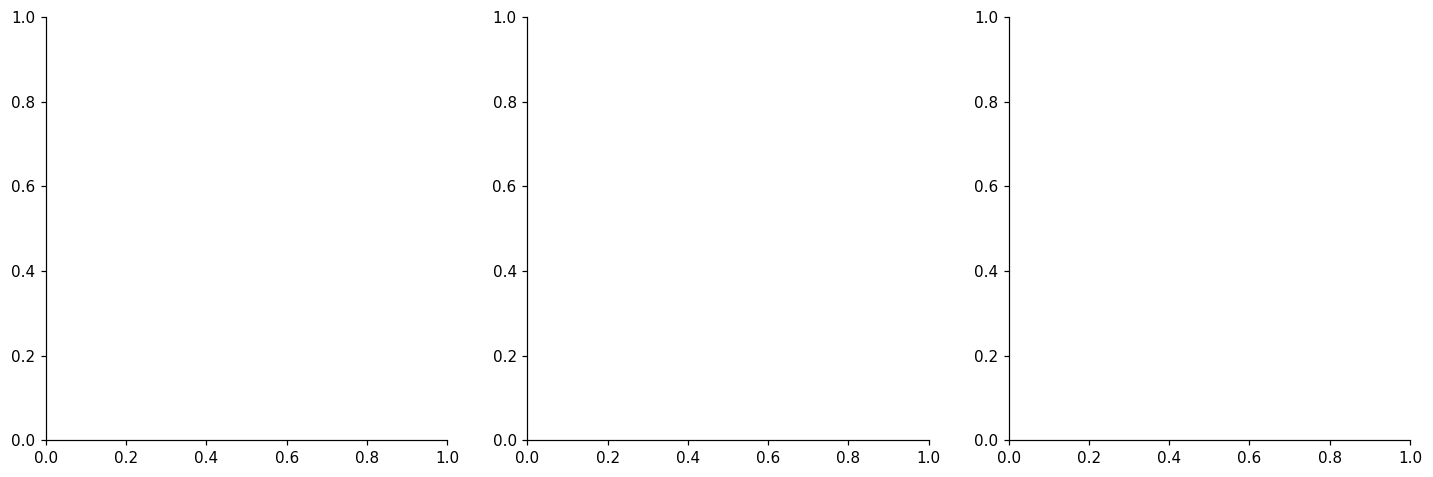

In [10]:
# ── t-SNE with different perplexity values ───────────────────────────────────
from sklearn.manifold import TSNE

perplexities = [5, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                n_iter=1000, learning_rate='auto', init='pca')
    Z_tsne = tsne.fit_transform(X)

    for k, name in enumerate(class_names):
        mask = y == k
        ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1], alpha=0.5, s=20,
                   color=colors[k], edgecolors='white', linewidth=0.2, label=name)

    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_title(f'Perplexity = {perp}', fontweight='bold')
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.suptitle('t-SNE: Perplexity Controls Neighborhood Size',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Low perplexity (5): focuses on very local structure → many small clusters")
print("High perplexity (100): considers broader neighborhoods → fewer, larger clusters")
print("Typical default: perplexity ≈ 30")

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

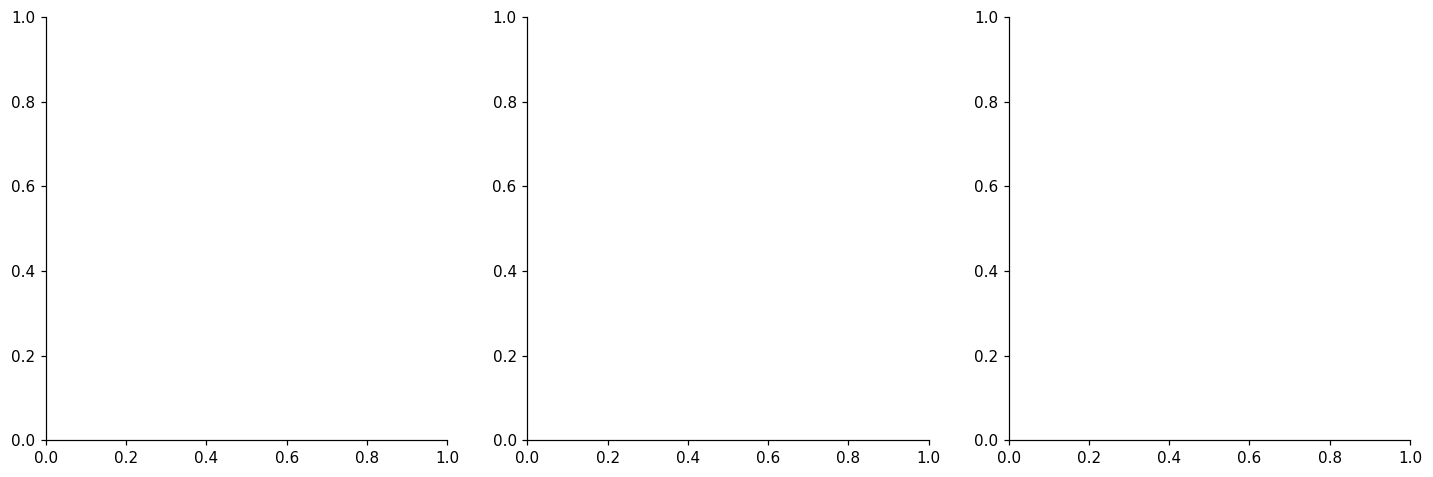

In [11]:
# ── t-SNE is stochastic: different seeds give different layouts ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, seed in zip(axes, [0, 42, 123]):
    tsne = TSNE(n_components=2, perplexity=30, random_state=seed,
                n_iter=1000, learning_rate='auto', init='pca')
    Z_tsne = tsne.fit_transform(X)

    for k, name in enumerate(class_names):
        mask = y == k
        ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1], alpha=0.5, s=20,
                   color=colors[k], edgecolors='white', linewidth=0.2, label=name)

    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_title(f'seed = {seed}', fontweight='bold')
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.suptitle('Same Data, Same Perplexity, Different Random Seeds → Different Layouts!',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("⚠️ The LAYOUT (position, orientation, cluster distances) changes across runs.")
print("   What's preserved: which points are NEAR each other (local neighborhoods).")
print("   What's NOT preserved: distances BETWEEN clusters, cluster sizes.")

### 🤔 Reflection 4.1 — Interpreting t-SNE (Carefully!)

1. The clusters look different across perplexity values and random seeds. Does the
   *distance between clusters* in a t-SNE plot have meaning? Does cluster *size*?
   (Answer: **no** and **no** — these are artifacts of the optimization. Only the
   *membership* of clusters is meaningful.)

2. You see two well-separated clusters in one t-SNE run. A colleague concludes
   "the classes are clearly separable!" What's wrong with this interpretation?

3. t-SNE is non-parametric — there's no projection function you can apply to new
   data. Why is this a serious limitation for clinical deployment? (If you train
   a model on t-SNE features, you can't apply it to a new patient.)

---
## Part 5 — UMAP: The Other End of the Spectrum

As described above, **UMAP** uses the same neighbor embedding framework as t-SNE but
with **negative sampling** instead of noise-contrastive estimation. In practice, this
means UMAP:

- Produces **tighter, more separated clusters** than t-SNE (because negative sampling
  introduces a distortion that "pushes" non-neighbors apart more aggressively with
  fewer negative samples)
- Better preserves **global structure** — the relative positions of clusters tend to
  be more meaningful
- Is significantly **faster** than t-SNE (negative sampling is cheaper per iteration)
- Is more **deterministic** across runs (though still stochastic)

UMAP also has a different implementation for computing high-dimensional similarities
(using a different kernel motivated by topological arguments), but Damrich et al. showed
that the main visual differences come from the negative sampling, not the kernel choice.

Key parameters:
- `n_neighbors`: controls local vs. global balance (analogous to t-SNE's perplexity).
  Small values emphasize fine local structure; large values emphasize broader patterns.
- `min_dist`: controls how tightly points are packed in the embedding. This is largely
  a cosmetic parameter — it affects visual density but not the neighborhood structure.

### Practical Guidance

When using t-SNE or UMAP for visualization:
1. **Don't over-interpret any single embedding.** Run both methods, vary parameters,
   and look for consistent patterns.
2. **Distances between clusters** are not reliable in either method (though slightly
   more so in UMAP). Only *neighborhood membership* is meaningful.
3. **Cluster size** in the embedding does not reflect cluster size in the original space.
4. If you see continuous structure (gradients) in t-SNE but discrete clusters in UMAP,
   the truth may be somewhere in between — this is the local/global trade-off at work.


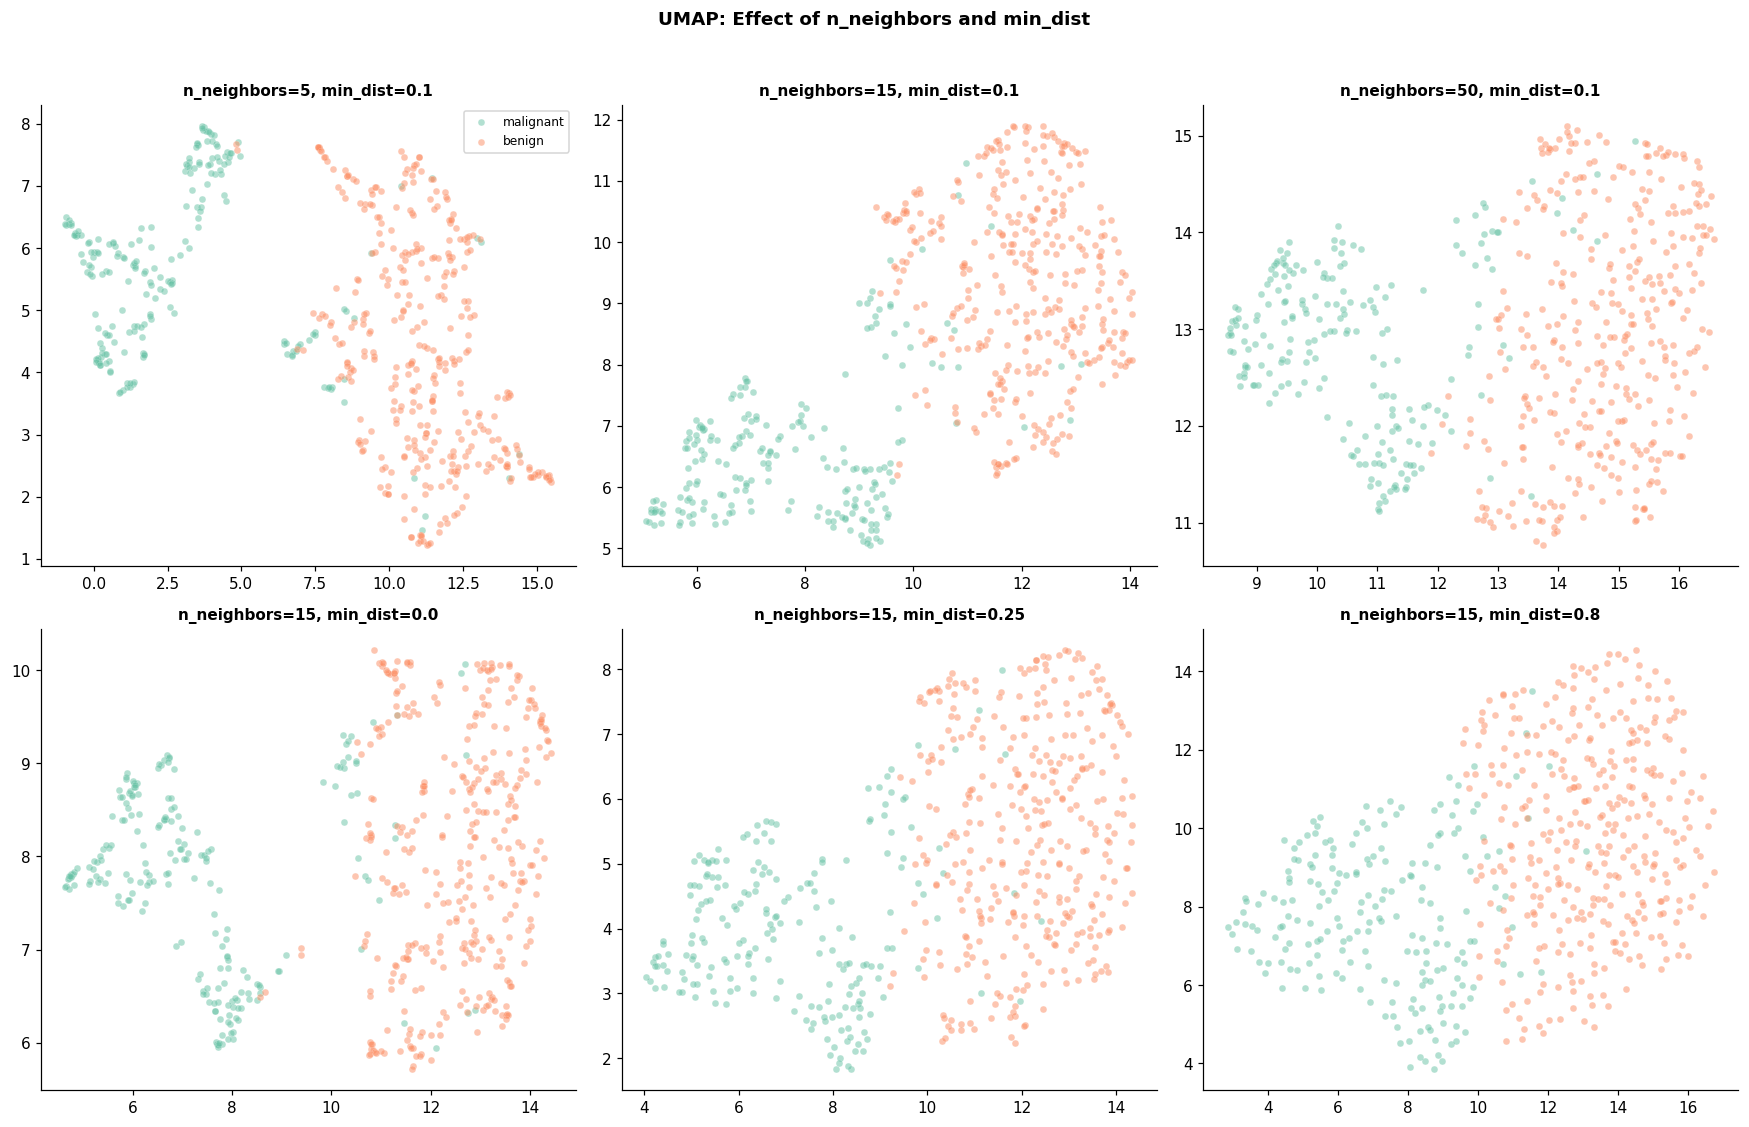

n_neighbors: small → local structure, large → global structure
min_dist: small → tight clusters, large → spread-out embedding


In [12]:
# ── UMAP with different parameters ───────────────────────────────────────────
import umap

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: vary n_neighbors (fixed min_dist=0.1)
for ax, nn in zip(axes[0], [5, 15, 50]):
    reducer = umap.UMAP(n_neighbors=nn, min_dist=0.1, random_state=42)
    Z_umap = reducer.fit_transform(X)

    for k, name in enumerate(class_names):
        mask = y == k
        ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1], alpha=0.5, s=20,
                   color=colors[k], edgecolors='white', linewidth=0.2, label=name)
    ax.set_title(f'n_neighbors={nn}, min_dist=0.1', fontweight='bold', fontsize=10)
    if ax == axes[0][0]:
        ax.legend(fontsize=8)

# Row 2: vary min_dist (fixed n_neighbors=15)
for ax, md in zip(axes[1], [0.0, 0.25, 0.8]):
    reducer = umap.UMAP(n_neighbors=15, min_dist=md, random_state=42)
    Z_umap = reducer.fit_transform(X)

    for k, name in enumerate(class_names):
        mask = y == k
        ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1], alpha=0.5, s=20,
                   color=colors[k], edgecolors='white', linewidth=0.2, label=name)
    ax.set_title(f'n_neighbors=15, min_dist={md}', fontweight='bold', fontsize=10)

plt.suptitle('UMAP: Effect of n_neighbors and min_dist', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("n_neighbors: small → local structure, large → global structure")
print("min_dist: small → tight clusters, large → spread-out embedding")

In [13]:
# ── Side-by-side: PCA vs. t-SNE vs. UMAP ────────────────────────────────────
Z_pca_2d = pca_full.transform(X)[:, :2]

tsne_default = TSNE(n_components=2, perplexity=30, random_state=42,
                     n_iter=1000, learning_rate='auto', init='pca')
Z_tsne_2d = tsne_default.fit_transform(X)

umap_default = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
Z_umap_2d = umap_default.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, Z_2d, title in zip(axes,
    [Z_pca_2d, Z_tsne_2d, Z_umap_2d],
    ['PCA', 't-SNE (perp=30)', 'UMAP (nn=15)']):

    for k, name in enumerate(class_names):
        mask = y == k
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], alpha=0.5, s=20,
                   color=colors[k], edgecolors='white', linewidth=0.2, label=name)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('PCA vs. t-SNE vs. UMAP: Same Data, Different Objectives',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("PCA:   linear, preserves global variance, interpretable axes")
print("t-SNE: nonlinear, preserves local neighborhoods, stochastic")
print("UMAP:  nonlinear, balances local + global, faster, more stable")

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

### 🤔 Reflection 5.1 — Comparing DR Methods (Unified View)

1. Damrich et al. showed that t-SNE and UMAP differ primarily in their use of
   contrastive estimation. UMAP's negative sampling produces tighter clusters.
   When you see "better separation" in UMAP, is that real structure in the data
   or an artifact of the negative sampling distortion?

2. PCA gives you interpretable axes (each PC is a weighted combination of original
   features). t-SNE and UMAP give you visually appealing plots with *no interpretable
   axes*. When is each more useful?

3. If t-SNE shows a continuous gradient within a cluster (e.g., cells transitioning
   between types) but UMAP shows two discrete subclusters, which should you trust?
   (Answer: neither, exclusively. The continuous structure in t-SNE and the discrete
   structure in UMAP reflect different points on the local/global emphasis spectrum.
   You should investigate with domain-specific tools.)

4. All three methods show separation between malignant and benign. But the *degree*
   of visual separation is very different. Which visualization would you show to a
   clinical audience? Which would you use for a technical audience? How would you
   caveat each?


---
## Part 6 — DR as Preprocessing for Downstream Tasks

Beyond visualization, DR can serve as a preprocessing step for supervised learning.
If most information is captured in a few components, training on those components
can be faster, more robust, and even improve performance (by removing noise).

In [14]:
# ── Compare classification performance with different feature sets ────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

results = []

# (a) Full 30-D features
lr_full = LogisticRegression(max_iter=2000, random_state=42)
lr_full.fit(X_train, y_train)
auc_full = roc_auc_score(y_val, lr_full.predict_proba(X_val)[:, 1])
results.append(('Full (30D)', 30, auc_full))

# (b) PCA with different numbers of components
for n_comp in [2, 5, 10, 15]:
    pca_k = PCA(n_components=n_comp, random_state=42)
    X_tr_pca = pca_k.fit_transform(X_train)
    X_vl_pca = pca_k.transform(X_val)

    lr_pca = LogisticRegression(max_iter=2000, random_state=42)
    lr_pca.fit(X_tr_pca, y_train)
    auc_pca = roc_auc_score(y_val, lr_pca.predict_proba(X_vl_pca)[:, 1])
    results.append((f'PCA ({n_comp}D)', n_comp, auc_pca))

# (c) UMAP 2-D embeddings
umap_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_tr_umap = umap_2d.fit_transform(X_train)
X_vl_umap = umap_2d.transform(X_val)

lr_umap = LogisticRegression(max_iter=2000, random_state=42)
lr_umap.fit(X_tr_umap, y_train)
auc_umap = roc_auc_score(y_val, lr_umap.predict_proba(X_vl_umap)[:, 1])
results.append(('UMAP (2D)', 2, auc_umap))

# Display results
results_df = pd.DataFrame(results, columns=['Features', 'Dims', 'Val AUROC'])
print(results_df.to_string(index=False, float_format='%.4f'))

  Features  Dims  Val AUROC
Full (30D)    30     1.0000
  PCA (2D)     2     0.9940
  PCA (5D)     5     0.9987
 PCA (10D)    10     1.0000
 PCA (15D)    15     1.0000
 UMAP (2D)     2     0.9977


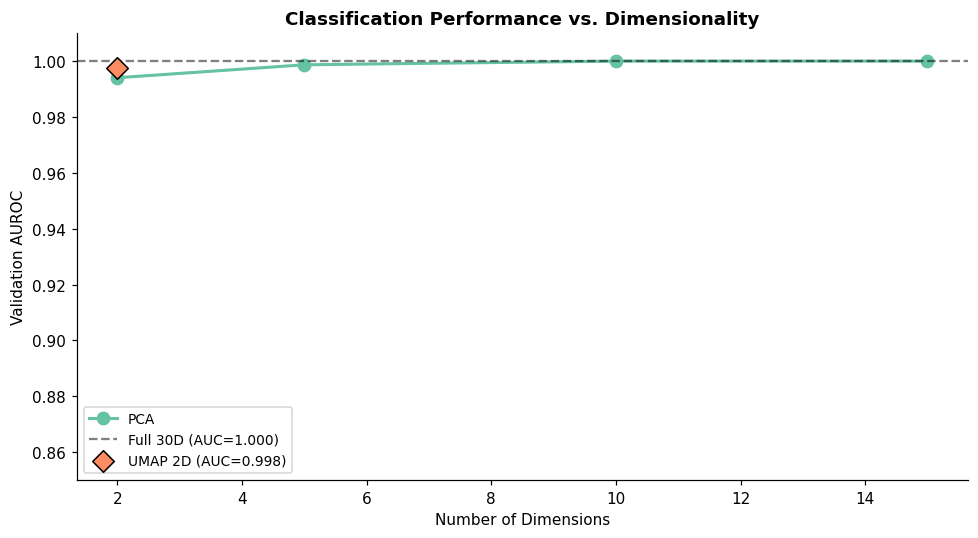

In [15]:
# ── Visualize AUC vs. dimensionality ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# PCA points
pca_results = [r for r in results if 'PCA' in r[0]]
ax.plot([r[1] for r in pca_results], [r[2] for r in pca_results],
        'o-', markersize=8, linewidth=2, label='PCA', color=sns.color_palette('Set2')[0])

# Full features
ax.axhline(auc_full, color='black', linestyle='--', alpha=0.5,
           label=f'Full 30D (AUC={auc_full:.3f})')

# UMAP
ax.scatter([2], [auc_umap], s=100, marker='D', color=sns.color_palette('Set2')[1],
           zorder=5, label=f'UMAP 2D (AUC={auc_umap:.3f})', edgecolors='black')

ax.set_xlabel('Number of Dimensions')
ax.set_ylabel('Validation AUROC')
ax.set_title('Classification Performance vs. Dimensionality', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.85, 1.01)
plt.tight_layout()
plt.show()

### 🤔 Reflection 6.1 — DR for Downstream Tasks

1. PCA with 10 components achieves nearly the same AUROC as full 30-D features. What
   does this tell you about the **intrinsic dimensionality** of this dataset? Would
   you expect the same pattern for a dataset with 20,000 gene expression features?

2. Would you use t-SNE or UMAP features for a **production** classifier? Why or why not?
   (Key issues: t-SNE can't transform new data at all. UMAP's `transform` is
   approximate and not guaranteed to be well-behaved. Both are stochastic.)

3. PCA preserves global variance, UMAP preserves local neighborhoods. If the decision
   boundary between classes depends on *local* structure (nearby points differ in class),
   which DR method might be better preprocessing? If it depends on *global* structure
   (classes are in different regions of feature space), which?

---
## Part 7 — Final Test Set Evaluation

Following the same protocol as all previous labs: evaluate the PCA-based classifier
on the held-out test set.

In [16]:
# ── Final test evaluation with PCA-10 ────────────────────────────────────────
# Retrain on train + val
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

pca_10 = PCA(n_components=10, random_state=42)
X_tv_pca = pca_10.fit_transform(X_tv)
X_test_pca = pca_10.transform(X_test)

lr_final = LogisticRegression(max_iter=2000, random_state=42)
lr_final.fit(X_tv_pca, y_tv)

auc_test_full = roc_auc_score(y_test,
    LogisticRegression(max_iter=2000, random_state=42).fit(X_tv, y_tv).predict_proba(X_test)[:, 1])
auc_test_pca10 = roc_auc_score(y_test, lr_final.predict_proba(X_test_pca)[:, 1])

print("═" * 60)
print("  FINAL TEST SET EVALUATION")
print("═" * 60)
print(f"  Full 30-D features:  AUROC = {auc_test_full:.4f}")
print(f"  PCA 10 components:   AUROC = {auc_test_pca10:.4f}")
print(f"  Dimensionality reduction: 30 → 10 ({10/30:.0%} of features)")
print(f"  Variance retained: {pca_10.explained_variance_ratio_.sum():.1%}")
print(f"  AUC change: {auc_test_pca10 - auc_test_full:+.4f}")
print("═" * 60)

════════════════════════════════════════════════════════════
  FINAL TEST SET EVALUATION
════════════════════════════════════════════════════════════
  Full 30-D features:  AUROC = 0.9967
  PCA 10 components:   AUROC = 0.9971
  Dimensionality reduction: 30 → 10 (33% of features)
  Variance retained: 95.5%
  AUC change: +0.0003
════════════════════════════════════════════════════════════


---
## 🤔 Final Reflection

You receive a **single-cell RNA-seq dataset** with 20,000 genes measured across
10,000 cells. Your collaborator wants to identify cell types and subtypes.

1. **Visualization:** Which method(s) would you use to produce 2-D plots for the
   collaborator? Would you use PCA, t-SNE, or UMAP — and with what parameters?
   What caveats would you mention when presenting the visualizations?

2. **Preprocessing for clustering:** You want to run K-Means or Leiden clustering
   to find cell types. Would you cluster on the full 20,000 features, on PCA
   components, or on UMAP embeddings? How many PCA components would you use?
   (Hint: the standard single-cell pipeline uses PCA → UMAP for visualization
   but PCA → graph-based clustering for cell type identification.)

3. **Feature importance:** After clustering, you want to find **marker genes** that
   distinguish each cell type. Can t-SNE or UMAP tell you which genes are important?
   Can PCA? What approach would you use instead? (Hint: differential expression
   testing on the original features, not the reduced dimensions.)

4. **Connection to the full lab series:** Across Labs 6–11, you've seen how the same
   data can answer fundamentally different questions depending on the *task formulation*:
   multi-class classification, regression, survival, probabilistic prediction,
   clustering, and dimensionality reduction. What's the common thread? (Answer: the
   choice of **loss function / objective** shapes what the model learns. The model
   architecture is secondary to what you ask it to optimize.)